# Self-study try-it activity 12.1: Analysing the effects of hyperparameters on surrogate models

In [1]:
import warnings
warnings.filterwarnings("ignore", message="Predicted variances smaller than 0. Setting those variances to 0.")
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF,RationalQuadratic, Matern
import matplotlib.pyplot as plt


import sklearn

To run this notebook, you’ll need scikit-learn version 1.0 or above. Use the cell below to check your current version. If it’s lower than 1.0, install the correct version before continuing by running the following command in your terminal:

`conda install scikit-learn=1.0`

In [2]:
print(sklearn.__version__)

1.9.0


## Gaussian process

Create the data set

In [3]:
np.random.seed(234) #Do not change the random seed
x = np.random.uniform(0, 10, (10, 1))

def true_function(x):
    return -(1.4 - 3.0 * x) * np.sin(x)

y = true_function(x)


In [4]:
y = y.ravel()  #Convert to 1D


In [5]:


kernel = 1.0 * RationalQuadratic(length_scale=1.0)
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=9)
gpr.fit(x, y)


,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP.If `None` is passed,the kernel `ConstantKernel() * RBF()` is used as default.Note thatthe kernel hyperparameters are optimized during fittingunless the bounds are marked as `""fixed""`or the argument `optimizer` is set to `None`.",1**2 * Ration...ength_scale=1)
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that `n_restarts_optimizer == 0` implies that onerun is performed.",9
,kernel__k1,1**2
,kernel__k2,RationalQuadr...ength_scale=1)
,kernel__k1__constant_value,1.0
,kernel__k1__constant_value_bounds,"(1e-05, ...)"
,kernel__k2__length_scale,1.0
,kernel__k2__alpha,1.0
,kernel__k2__length_scale_bounds,"(1e-05, ...)"
,kernel__k2__alpha_bounds,"(1e-05, ...)"
,"alpha alpha: float or ndarray of shape (n_samples,), default=1e-10Value added to the diagonal of the kernel matrix during fitting.This can prevent a potential numerical issue during fitting, byensuring that the calculated values form a positive definite matrix.It can also be interpreted as the variance of additional Gaussianmeasurement noise on the training observations. Note that this isdifferent from using a `WhiteKernel`. If an array is passed, it musthave the same number of entries as the data used for fitting and isused as datapoint-dependent noise level. Allowing to specify thenoise level directly as a parameter is mainly for convenience andfor consistency with :class:`~sklearn.linear_model.Ridge`.For an example illustrating how the alpha parameter controlsthe noise variance in Gaussian Process Regression, see:ref:`sphx_glr_auto_examples_gaussian_process_plot_gpr_noisy_targets.py`.",1e-10


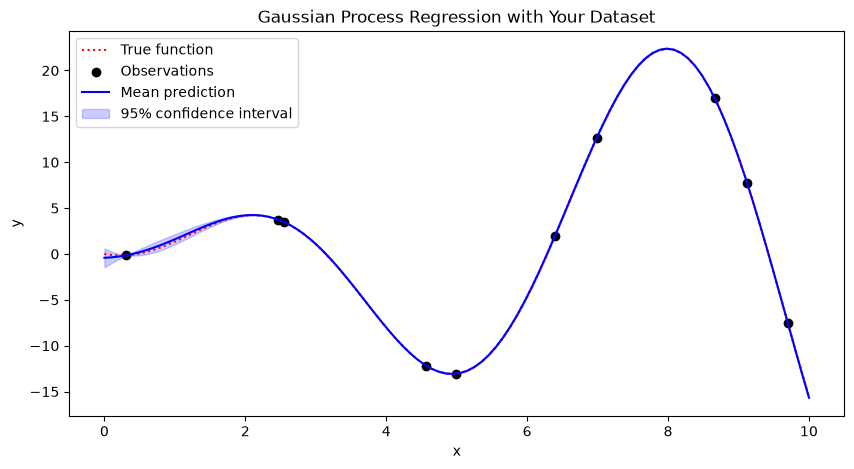

In [6]:
import matplotlib.pyplot as plt

#Create test points
x_test = np.linspace(0, 10, 100).reshape(-1, 1)
y_pred, std = gpr.predict(x_test, return_std=True)

#Plot
plt.figure(figsize=(10, 5))
plt.plot(x_test, true_function(x_test), 'r:', label='True function')
plt.scatter(x, y, c='k', label='Observations')
plt.plot(x_test, y_pred, 'b-', label='Mean prediction')
plt.fill_between(x_test.ravel(),
                 y_pred - 1.96 * std,
                 y_pred + 1.96 * std,
                 alpha=0.2, color='blue', label='95% confidence interval')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('Gaussian Process Regression with Your Dataset')
plt.show()


## Answer the following questions

- Change the `length_scale` and observe the changes in the plot.

- Change the `kernel` to `Matern` and `RationalQuadratic` and observe the changes in the plot.

- Change the confidence intervals as follows and observe the plots:

  a. 68% confidence interval

  b. 90% confidence interval

  c. 99% confidence interval

## Regression tree parameters

Explore how model parameters can affect the quality of the prediction.

## Follow these steps:

- Experiment with the hyperparameters of the regression trees below to build both the best and worst models you can.

- Use `help(DecisionTreeRegressor)` to explore the available hyperparameter options.

In [ ]:
x_test = np.linspace(0, 10, 100).reshape(100, 1)

In [7]:
from sklearn.tree import DecisionTreeRegressor
# Over-constrained "worst" tree → trivial splits
clf_worst = DecisionTreeRegressor(criterion="squared_error",
                            splitter='random',
                            max_depth=3,
                            min_samples_split=2,
                            min_samples_leaf=3,
                            min_weight_fraction_leaf=0.2,
                            max_features=1,
                            max_leaf_nodes=2,
                            min_impurity_decrease=1.0)

print(clf_worst.criterion)

clf_worst.fit(x, y)# fit on tiny dataset

clf_best = DecisionTreeRegressor(criterion='absolute_error',
                            splitter='random',
                            max_depth=3,
                            min_samples_split=2,
                            min_samples_leaf=3,
                            min_weight_fraction_leaf=0.2,
                            max_features=1,
                            max_leaf_nodes=2,
                            min_impurity_decrease=1.0)

clf_best.fit(x, y)

y_test_worst = clf_worst.predict(x_test)
y_test_best = clf_best.predict(x_test)
y_true = true_function(x_test)

squared_error


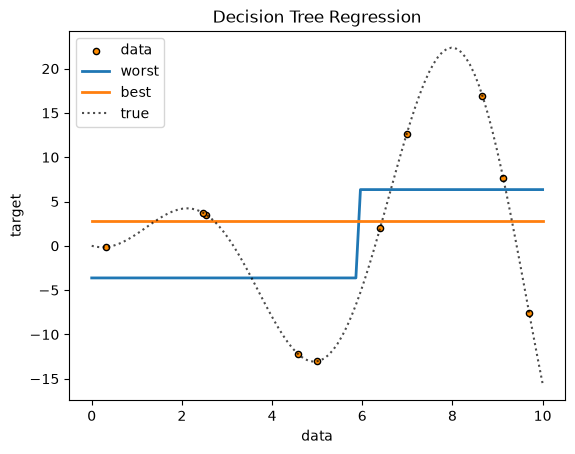

In [8]:
plt.figure()
# Plot shows: true function (black), best-fit tree (blue), worst-fit tree (orange).
# Highlights underfitting vs. closer fit to ground truth.
plt.scatter(x, y, s=20, edgecolor="black", c="darkorange", label="data")
plt.plot(x_test, y_test_worst,  linewidth=2, label='worst')
plt.plot(x_test, y_test_best, linewidth=2, label='best')
plt.plot(x_test, y_true, color='k', linestyle=":", alpha=0.7, label='true')
plt.xlabel("data")
plt.ylabel("target")
plt.title("Decision Tree Regression")
plt.legend()
plt.show()